## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [4]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../Modules")
sys.path.insert(0, "../../Mamoth")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
NUTS0 = 'GR'

In [8]:
mosquito_data = read_data(f'../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [9]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [11]:
mosquito_data_nuts2 = mosquito_data
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [12]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [13]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

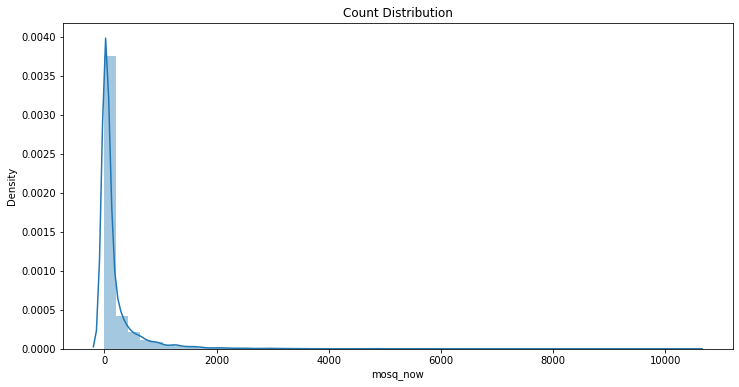

In [14]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [15]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

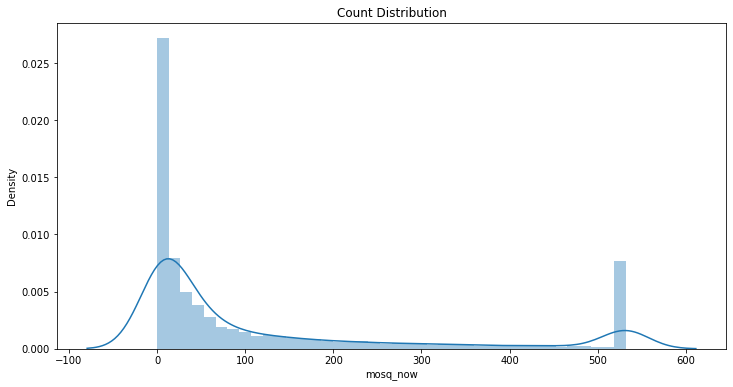

In [16]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

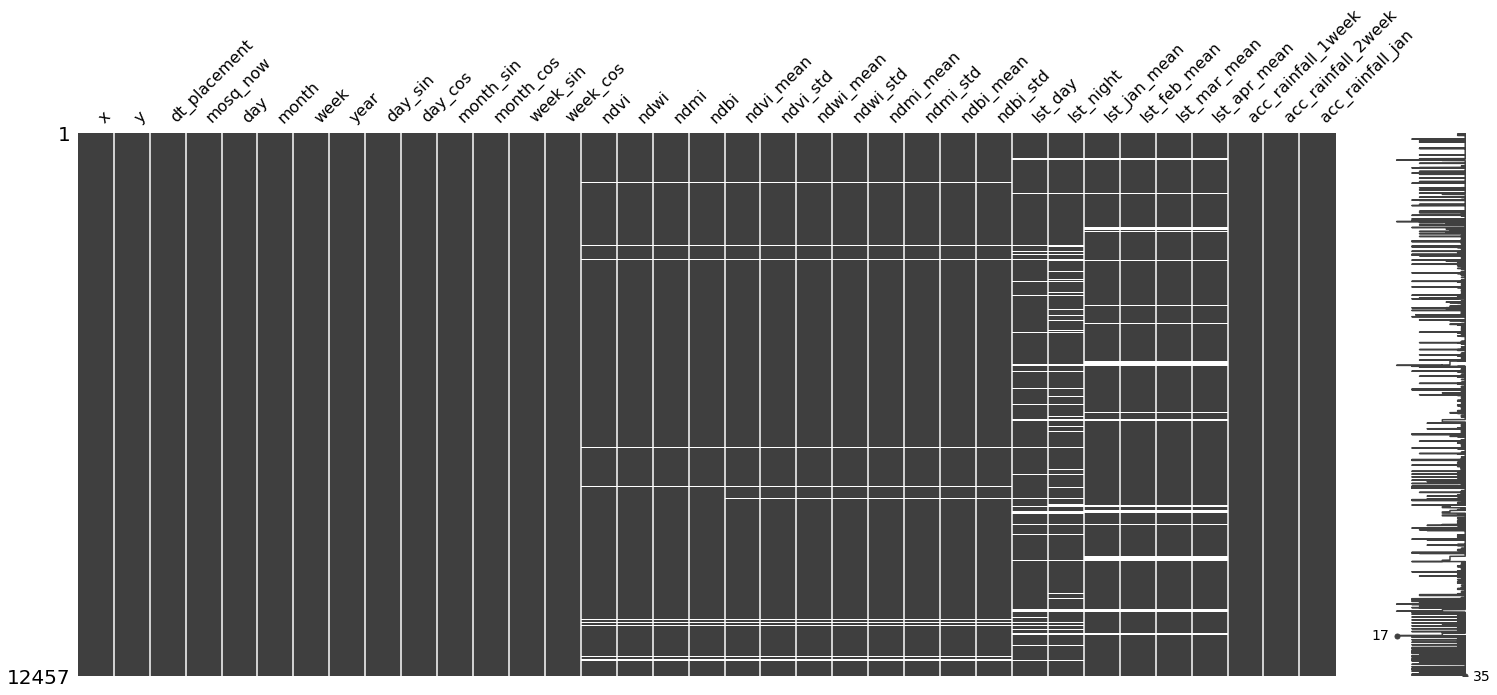

In [17]:
missingno.matrix(mosquito_data_nuts2)

In [18]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [19]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

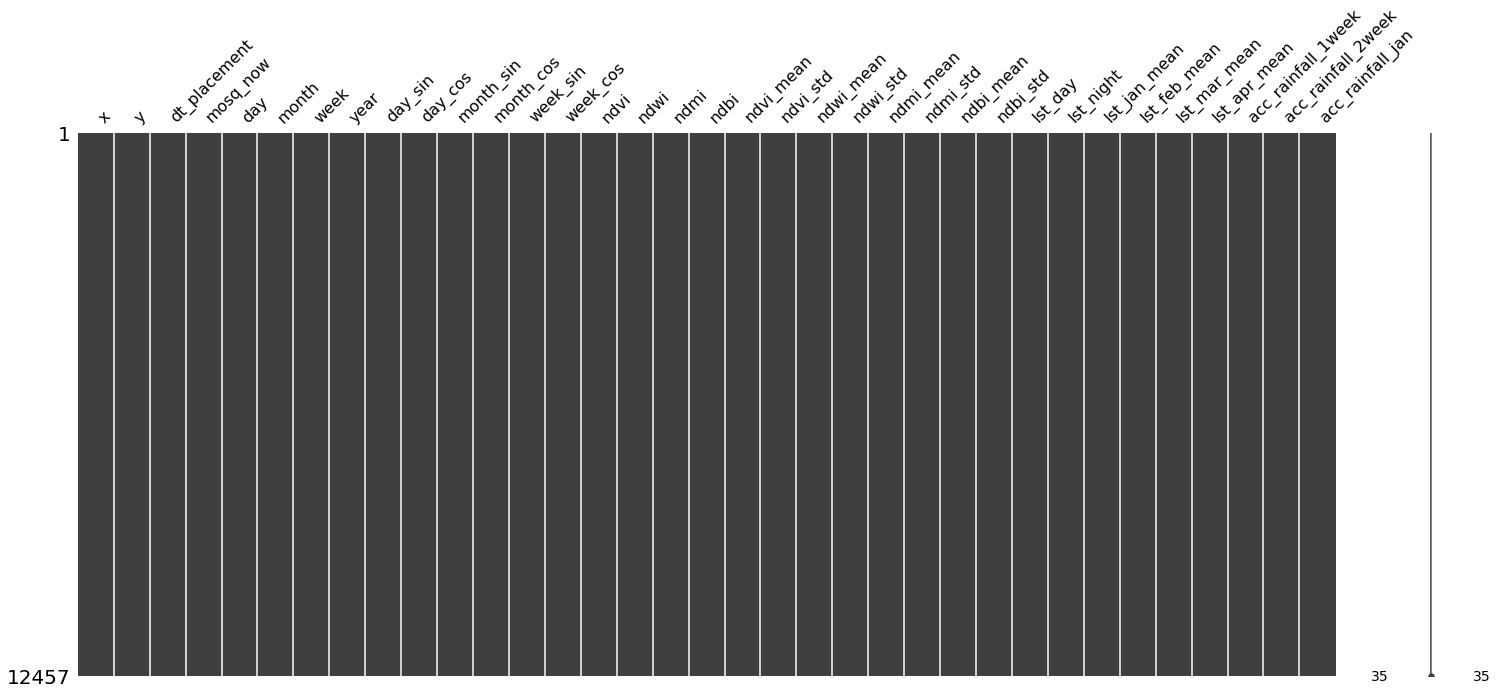

In [20]:
missingno.matrix(mosquito_data_nuts2)

In [21]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [22]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  33. 532.]


In [23]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.26264 | Val Loss: 71.03204 | Train Acc: 3.402| Val Acc: 4.528
Epoch 002: | Train Loss: 42.80383 | Val Loss: 45.77457 | Train Acc: 3.421| Val Acc: 3.558
Epoch 003: | Train Loss: 41.45746 | Val Loss: 44.70165 | Train Acc: 3.303| Val Acc: 3.310
Epoch 004: | Train Loss: 41.23305 | Val Loss: 44.82217 | Train Acc: 3.256| Val Acc: 3.343
Epoch 005: | Train Loss: 40.98876 | Val Loss: 44.78613 | Train Acc: 3.238| Val Acc: 3.171
Epoch 006: | Train Loss: 40.68884 | Val Loss: 45.04301 | Train Acc: 3.177| Val Acc: 3.182
Epoch 007: | Train Loss: 40.61429 | Val Loss: 44.87154 | Train Acc: 3.180| Val Acc: 3.197
Epoch 008: | Train Loss: 40.21110 | Val Loss: 44.90768 | Train Acc: 3.114| Val Acc: 3.146
Epoch 009: | Train Loss: 40.03404 | Val Loss: 44.67079 | Train Acc: 3.082| Val Acc: 3.092
Epoch 010: | Train Loss: 39.77150 | Val Loss: 44.84512 | Train Acc: 3.049| Val Acc: 3.123
Epoch 011: | Train Loss: 39.64175 | Val Loss: 45.17182 | Train Acc: 3.020| Val Acc: 3.123
Epoch 012:

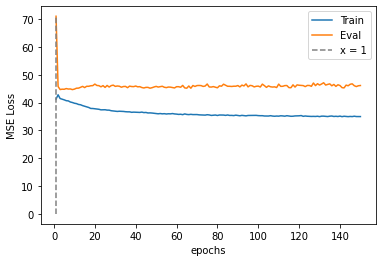

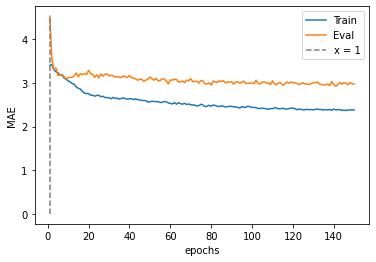

In [24]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [25]:
metrics(train, test, threshold=30)

MAE on train set:  101.72770802192049
min prediction: 1
max prediction: 670

MAE on test set:  101.86301101501407
Error ⩽ 30: 26.89 %
min prediction: 1
max prediction: 588


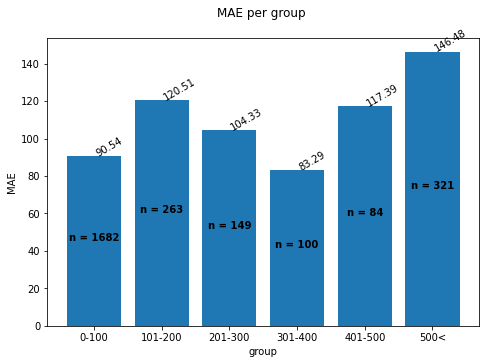

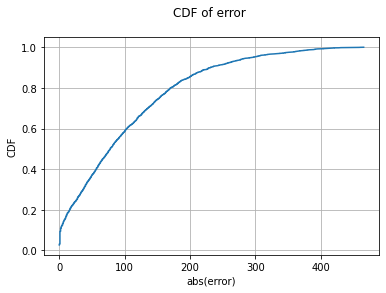

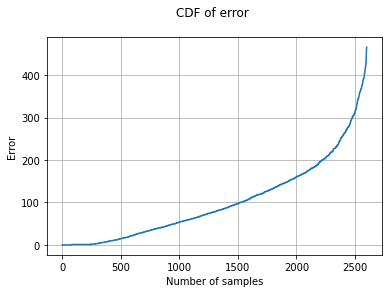

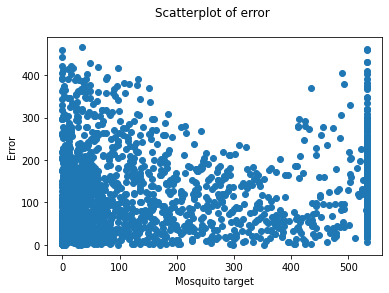

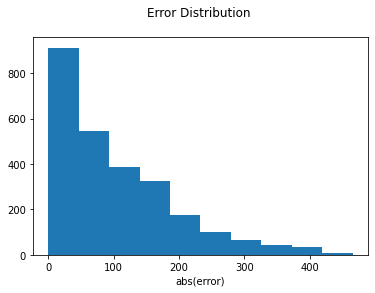

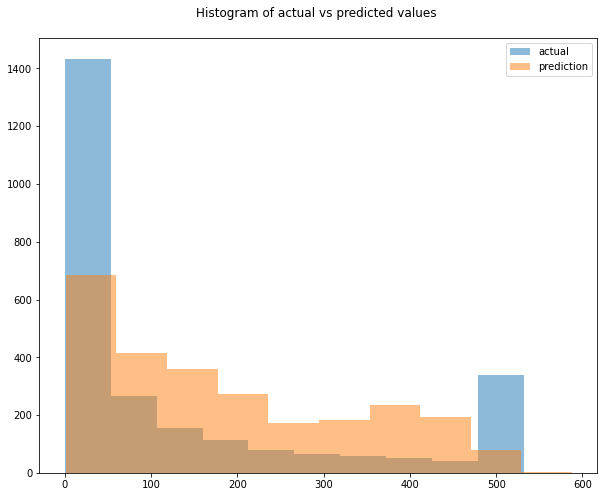

In [26]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 34.70334 | Val Loss: 0.01725 | Train Acc: 2.421| Val Acc: 0.142
Epoch 002: | Train Loss: 34.65429 | Val Loss: 0.02600 | Train Acc: 2.422| Val Acc: 0.142
Epoch 003: | Train Loss: 34.55764 | Val Loss: 0.01442 | Train Acc: 2.401| Val Acc: 0.142
Epoch 004: | Train Loss: 34.37669 | Val Loss: 0.01273 | Train Acc: 2.388| Val Acc: 0.142
Epoch 005: | Train Loss: 34.36901 | Val Loss: 0.00658 | Train Acc: 2.379| Val Acc: 0.142
Epoch 006: | Train Loss: 34.43879 | Val Loss: 0.00536 | Train Acc: 2.404| Val Acc: 0.142
Epoch 007: | Train Loss: 34.45321 | Val Loss: 0.18474 | Train Acc: 2.409| Val Acc: 0.858
Epoch 008: | Train Loss: 34.49746 | Val Loss: 0.04754 | Train Acc: 2.405| Val Acc: 0.142
Epoch 009: | Train Loss: 34.21624 | Val Loss: 0.00846 | Train Acc: 2.361| Val Acc: 0.142
Epoch 010: | Train Loss: 34.23271 | Val Loss: 0.02084 | Train Acc: 2.359| Val Acc: 0.142
Epoch 011: | Train Loss: 34.28899 | Val Loss: 0.03440 | Train Acc: 2.387| Val Acc: 0.142
Epoch 012: | Train Lo

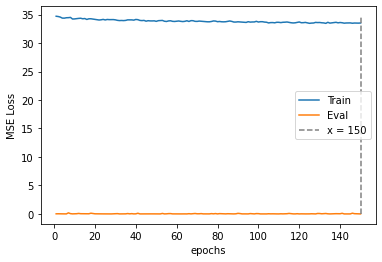

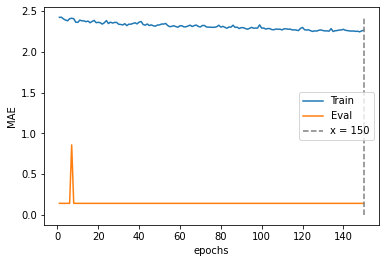

In [27]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [28]:
pickle.dump(model, open(f'../data/{NUTS0}_NUTS3_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../data/{NUTS0}_NUTS3_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../data/{NUTS0}_NUTS3_Culex_Scaler.pkl', 'wb'))